In [72]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns

In [125]:
df = pd.read_csv("anime.csv")

In [126]:
df.head()

,Rank,Title,Score
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05


In [127]:
df["Title"][0]

'Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr 2009 - Jul 20103,218,472 membersManga StoreVolume 1€4.58Preview'

In [128]:
def ext_name(txt):
    check = True
    data = ""
    for i in range(len(txt)):
        if txt[i] == "(":
            check = False
            break
        if check == True:
            data = data + txt[i]
    data = data.strip()
    return data
         

In [129]:
df["Name"] = df["Title"].apply(ext_name)

In [130]:
df.head()

,Rank,Title,Score,Name
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: BrotherhoodTV
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;GateTV
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-henTV
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°TV
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2TV


In [131]:
df[["Name", "Type"]] = df["Title"].str.extract(r'^(.*?)(TV|Movie|OVA|ONA|Special|Music)\s*\(')
df["Name"] = df["Name"].str.strip()

df.head()

,Rank,Title,Score,Name,Type
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV


In [132]:
def esxt_eps(txt) :
    check = False
    data = ""
    for i in txt :
        if i == ")":
            check = False
            return data
        if check == True :
            data = data + i
        if i == "(":
            check = True

In [133]:
df["episodes"] = df["Title"].apply(esxt_eps)

In [134]:
df.head()

,Rank,Title,Score,Name,Type,episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64 eps
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24 eps
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13 eps
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51 eps
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10 eps


In [135]:
df["episodes"] = df["episodes"].str.replace(" eps", "")

In [136]:
df["episodes"] = df["episodes"].astype(int)

In [137]:
df.head()

,Rank,Title,Score,Name,Type,episodes
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10


In [138]:
def exct_time(txt):
    check = False
    data = ""
    for i in range(len(txt)) :
        if txt[i] == ")":
            for j in range(i+1, i+20):
                data = data + txt[j]
            return data

In [139]:
df["Total time"] = df["Title"].apply(exct_time)

In [140]:
df.head()

,Rank,Title,Score,Name,Type,episodes,Total time
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24,Apr 2011 - Sep 2011
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13,Oct 2022 - Dec 2022
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51,Apr 2015 - Mar 2016
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10,Apr 2019 - Jul 2019


In [141]:
def get_month_duration(value):
    start, end = value.split(" - ")
    
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    return (end.year - start.year) * 12 + (end.month - start.month) + 1

df["duration_months"] = df["Total time"].apply(get_month_duration)

In [142]:
df.head()

,Rank,Title,Score,Name,Type,episodes,Total time,duration_months
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24,Apr 2011 - Sep 2011,6
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13,Oct 2022 - Dec 2022,3
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51,Apr 2015 - Mar 2016,12
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10,Apr 2019 - Jul 2019,4


In [143]:
def ext_members(txt):
    block = ""
    collecting = False

    for i in range(len(txt)):
        if txt[i].isdigit() or txt[i] == ",":
            collecting = True
            block = block + txt[i]
        elif txt[i] == " " and collecting:
            continue  # allow a space between number and "members"
        elif txt[i] == "m" and collecting:
            break
        elif collecting:
            # hit a non-digit/comma/space char before "members" — reset
            block = ""
            collecting = False

    return block[4:] if len(block) > 4 else None

In [148]:
df["members"] = (
    df["Title"]
    .apply(ext_members)
    .str.replace(",", "", regex=False)
    .astype("int64"))

In [149]:
df.head()

,Rank,Title,Score,Name,Type,episodes,Total time,duration_months,members
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16,3218472
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24,Apr 2011 - Sep 2011,6,2473707
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13,Oct 2022 - Dec 2022,3,474138
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51,Apr 2015 - Mar 2016,12,605113
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10,Apr 2019 - Jul 2019,4,2146679


In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             50 non-null     int64  
 1   Title            50 non-null     str    
 2   Score            50 non-null     float64
 3   Name             50 non-null     str    
 4   Type             50 non-null     str    
 5   episodes         50 non-null     int64  
 6   Total time       50 non-null     str    
 7   duration_months  50 non-null     int64  
 8   members          50 non-null     int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 3.6 KB


In [95]:
import pandas as pd

df["Preview"] = df["Title"].str.extract(r'(€[\d.]+)Preview')
df["Preview"] = df["Preview"].str.replace("€", "", regex=False).astype(float)

df.head()

,Rank,Title,Score,Name,Type,episodes,Total time,duration_months,members,Preview
0,1,Fullmetal Alchemist: BrotherhoodTV (64 eps)Apr...,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16,"3,218,472",4.58
1,2,"Steins;GateTV (24 eps)Apr 2011 - Sep 20112,473...",9.07,Steins;Gate,TV,24,Apr 2011 - Sep 2011,6,"2,473,707",NaN
2,3,Bleach: Sennen Kessen-henTV (13 eps)Oct 2022 -...,9.06,Bleach: Sennen Kessen-hen,TV,13,Oct 2022 - Dec 2022,3,"474,138",NaN
3,4,"Gintama°TV (51 eps)Apr 2015 - Mar 2016605,113 ...",9.06,Gintama°,TV,51,Apr 2015 - Mar 2016,12,"605,113",NaN
4,5,Shingeki no Kyojin Season 3 Part 2TV (10 eps)A...,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10,Apr 2019 - Jul 2019,4,"2,146,679",10.99


In [96]:
df.drop("Title" , inplace = True , axis = 1)

In [97]:
df.head()

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
0,1,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16,"3,218,472",4.58
1,2,9.07,Steins;Gate,TV,24,Apr 2011 - Sep 2011,6,"2,473,707",NaN
2,3,9.06,Bleach: Sennen Kessen-hen,TV,13,Oct 2022 - Dec 2022,3,"474,138",NaN
3,4,9.06,Gintama°,TV,51,Apr 2015 - Mar 2016,12,"605,113",NaN
4,5,9.05,Shingeki no Kyojin Season 3 Part 2,TV,10,Apr 2019 - Jul 2019,4,"2,146,679",10.99


In [98]:
df[df["episodes"] == df["episodes"].max()]

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
15,16,8.94,Gintama,TV,201,Apr 2006 - Mar 2010,48,"1,034,418",NaN


In [99]:
df[df["Score"] == df["Score"].max()]

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
0,1,9.1,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16,"3,218,472",4.58


In [100]:
df[df["duration_months"] == df["duration_months"].min()]

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
6,7,9.04,Gintama: The Final,Movie,1,Jan 2021 - Jan 2021,1,"137,208",NaN
16,17,8.94,Koe no Katachi,Movie,1,Sep 2016 - Sep 2016,1,"2,228,957",10.99
20,21,8.91,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,Movie,1,Jul 2013 - Jul 2013,1,"232,388",NaN
21,22,8.89,Violet Evergarden Movie,Movie,1,Sep 2020 - Sep 2020,1,"564,225",NaN
22,23,8.88,Owarimonogatari 2nd Season,TV,7,Aug 2017 - Aug 2017,1,"385,248",NaN
25,26,8.84,Kimi no Na wa.,Movie,1,Aug 2016 - Aug 2016,1,"2,635,814",4.58
26,27,8.84,Kaguya-sama wa Kokurasetai: First Kiss wa Owar...,Movie,1,Dec 2022 - Dec 2022,1,"205,150",NaN
28,29,8.83,The First Slam Dunk,Movie,1,Dec 2022 - Dec 2022,1,"27,063",NaN
36,37,8.79,Kizumonogatari III: Reiketsu-hen,Movie,1,Jan 2017 - Jan 2017,1,"445,640",9.99
39,40,8.78,Sen to Chihiro no Kamikakushi,Movie,1,Jul 2001 - Jul 2001,1,"1,784,960",NaN


In [101]:
df[df["Preview"] == df["Preview"].max()]

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
29,30,8.82,Vinland Saga Season 2,TV,24,Jan 2023 - Jun 2023,6,"495,454",17.99
45,46,8.74,Vinland Saga,TV,24,Jul 2019 - Dec 2019,6,"1,403,669",17.99


In [102]:
df[df["Preview"] == df["Preview"].min()]

,Rank,Score,Name,Type,episodes,Total time,duration_months,members,Preview
0,1,9.10,Fullmetal Alchemist: Brotherhood,TV,64,Apr 2009 - Jul 2010,16,"3,218,472",4.58
25,26,8.84,Kimi no Na wa.,Movie,1,Aug 2016 - Aug 2016,1,"2,635,814",4.58


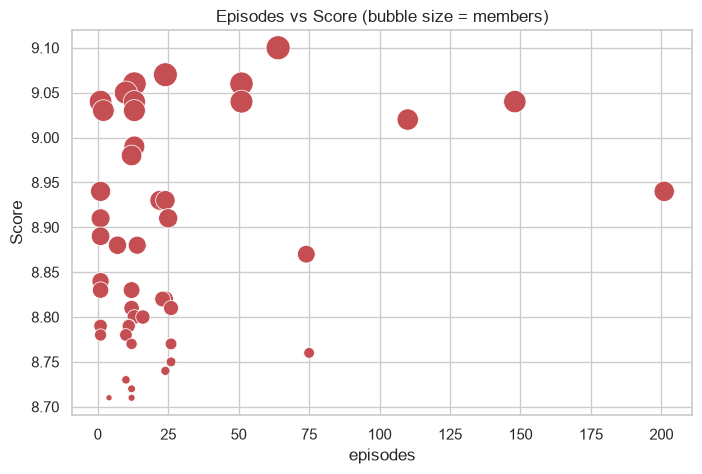

In [107]:
#sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="episodes",
    y="Score",
    size="members",       # bubble size reflects member count
    sizes=(20, 300),      # min/max bubble size in points
    data=df,
    legend=False,
    color="#C44E52"
)
plt.title("Episodes vs Score (bubble size = members)")
#plt.xlim(0, 80)  # excludes Gintama (201 eps) and Hunter x Hunter (148 eps) so the rest is readable
plt.show()

**Observation:** Episode count has only a weak positive relationship with score (correlation ≈ 0.26). Most titles in this top-50 list run under ~65 episodes, and the two long-runners, Gintama (201 eps) and Hunter x Hunter (148 eps), still score competitively (8.94+) rather than dragging the average down. Episode count alone isn't a useful predictor of quality here — it's more a reflection of format/genre than score.

In [151]:
corr = df.corr(numeric_only = True)
corr

,Rank,Score,episodes,duration_months,members
Rank,1.000000,-0.987586,-0.246157,-0.196988,-0.204497
Score,-0.987586,1.000000,0.260452,0.231570,0.203409
episodes,-0.246157,0.260452,1.000000,0.740586,0.215928
duration_months,-0.196988,0.231570,0.740586,1.000000,0.035780
members,-0.204497,0.203409,0.215928,0.035780,1.000000


In [154]:
df_corr = df[["members" , "Score" , "Rank"]]
corr2 = df_corr.corr()
corr2

,members,Score,Rank
members,1.000000,0.203409,-0.204497
Score,0.203409,1.000000,-0.987586
Rank,-0.204497,-0.987586,1.000000


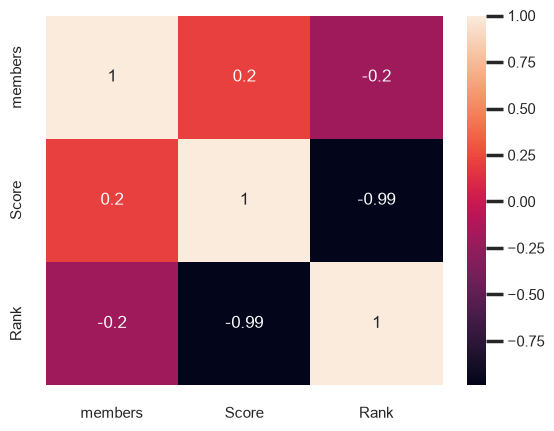

In [155]:
#plt.figure(figsize = (5,3))
sns.set_context("poster", font_scale = 0.5 )
sns.heatmap(corr2 ,annot = True )
plt.show()

**Observation:** Rank and Score are almost perfectly negatively correlated (-0.99), which is expected since rank is directly derived from score. Members (popularity) has only a weak positive correlation with Score (0.20) and a weak negative correlation with Rank (-0.20) — among this list of already highly-rated anime, being more popular doesn't meaningfully predict a higher score. This makes sense: once a title is elite enough to make a top-50 list, popularity and quality decouple.

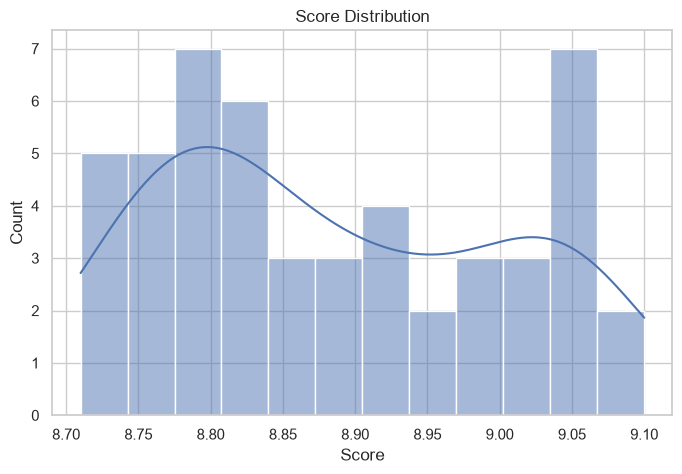

In [158]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(
    df["Score"],
    bins=12,
    kde=True,          # overlays a smooth density curve on top of the bars
    color="#4C72B0"
)
plt.title("Score Distribution")
plt.show()

**Observation:** Scores are tightly clustered between 8.71 and 9.10 (mean 8.88, std ≈ 0.12). This narrow spread is expected — the dataset only contains the top 50 highest-rated anime, so there's a strong survivorship-bias effect: we're looking at the ceiling of the score distribution, not a representative sample of all anime.

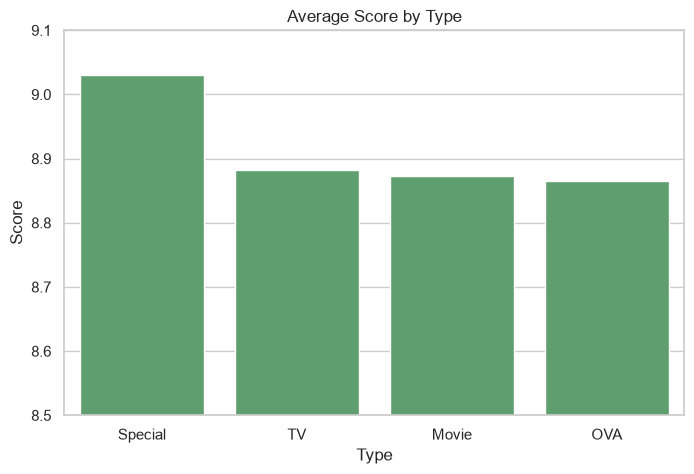

In [160]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
order = df.groupby("Type")["Score"].mean().sort_values(ascending=False).index

sns.barplot(
    x="Type",
    y="Score",
    data=df,
    estimator="mean",
    errorbar=None,     # hides the confidence-interval error bars
    order=order,        # sorts bars from highest to lowest average score
    color="#55A868"
)
plt.title("Average Score by Type")
plt.ylim(8.5, 9.1)      # zooms in on the relevant range instead of starting at 0
plt.show()

**Observation:** TV series dominate the list (38 of 50 titles) and average 8.88, close to Movies (9 titles, 8.87) and OVA (2 titles, 8.87). "Special" shows the highest average (9.03) but that's based on a single title, so it isn't a meaningful comparison. Note the y-axis is zoomed to 8.5–9.1 to make these differences visible — on a full 0–10 scale, average scores by type are essentially the same.

## Conclusion

This dataset covers the top 50 highest-rated anime on the source site (scores 8.71–9.10). A few takeaways from the analysis:

- **Rank is a direct function of Score** (correlation ≈ -0.99), so any "what predicts rank" question reduces to "what predicts score."
- **Episode count and duration_months show little relationship with score** (correlations of 0.26 and 0.23 respectively) — how long a series runs doesn't meaningfully explain why it's rated highly.
- **Popularity (members) is only weakly related to score** (0.20) within this elite subset — being widely watched doesn't strongly correlate with being top-rated once a title has already reached this tier.
- **Score differences across Type (TV/Movie/OVA/Special) are small** and partly an artifact of very uneven group sizes (38 TV titles vs. 1 Special) — not strong evidence that format drives quality.
- **The `Preview` (price) field is only populated for 14 of 50 titles**, so it reflects partial merchandise-listing data rather than a property of the anime itself, and any conclusions from it should be treated as limited.

Overall, within this top-50 slice, score doesn't have a strong linear relationship with episode count, duration, popularity, or type — the ranking is likely driven more by qualitative reception than by any of these numeric attributes.